# $(SASA) Baseline$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Base_Line_Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
1714,9,72,"(0.67, 1.6)","(0.017, 0.141, -0.03, -0.232)",0,1.0,"(0.02, -0.047, -0.035, -0.08)",0.0,1.0,"(0.019, -0.236, -0.037, 0.071)"
1015,5,45,"(0.95, 1.3)","(-0.008, -0.195, 0.055, 0.381)",0,1.0,"(-0.012, -0.391, 0.063, 0.694)",1.0,1.0,"(-0.02, -0.197, 0.077, 0.419)"
708,6,30,"(0.87, 1.2)","(-0.015, 0.385, -0.06, -0.621)",1,1.0,"(-0.008, 0.58, -0.072, -0.917)",0.0,1.0,"(0.004, 0.387, -0.091, -0.662)"
2091,9,89,"(0.85, 1.4)","(0.105, 0.606, -0.096, -0.779)",1,1.0,"(0.117, 0.799, -0.111, -1.031)",1.0,1.0,"(0.133, 0.992, -0.132, -1.284)"
798,10,36,"(0.41, 0.8)","(-0.054, -0.015, 0.071, 0.107)",1,1.0,"(-0.054, 0.176, 0.073, -0.11)",0.0,1.0,"(-0.05, -0.017, 0.071, 0.144)"
...,...,...,...,...,...,...,...,...,...,...
1074,9,47,"(0.14, 0.0)","(-0.002, -0.56, 0.035, 0.84)",0,1.0,"(-0.014, -0.756, 0.052, 1.153)",1.0,1.0,"(-0.029, -0.561, 0.075, 0.868)"
776,1,35,"(0.77, 0.0)","(-0.016, -0.213, 0.044, 0.644)",1,1.0,"(-0.021, -0.007, 0.057, 0.099)",1.0,1.0,"(-0.021, 0.2, 0.059, -0.437)"
2032,6,86,"(0.26, 0.5)","(-0.02, -0.822, 0.058, 1.356)",0,1.0,"(-0.036, -1.02, 0.085, 1.707)",1.0,1.0,"(-0.057, -0.824, 0.119, 1.407)"
2257,28,98,"(0.64, 1.6)","(-0.146, -0.345, 0.096, 0.353)",1,1.0,"(-0.153, -0.158, 0.103, 0.219)",0.0,1.0,"(-0.156, -0.347, 0.107, 0.385)"


In [3]:
model = Base_Line_Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=500)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_s,transition,reward
0,0,"[0.06072153151035309, 0.43242764472961426, 0.0...",1.633013,1.041286
1,1,"[0.059069789946079254, 0.42728063464164734, 0....",1.614552,1.033270
2,2,"[0.057451073080301285, 0.422166645526886, 0.03...",1.596253,1.025346
3,3,"[0.05586481839418411, 0.4170888364315033, 0.03...",1.578117,1.017521
4,4,"[0.05431129410862923, 0.41204771399497986, 0.0...",1.560141,1.009806


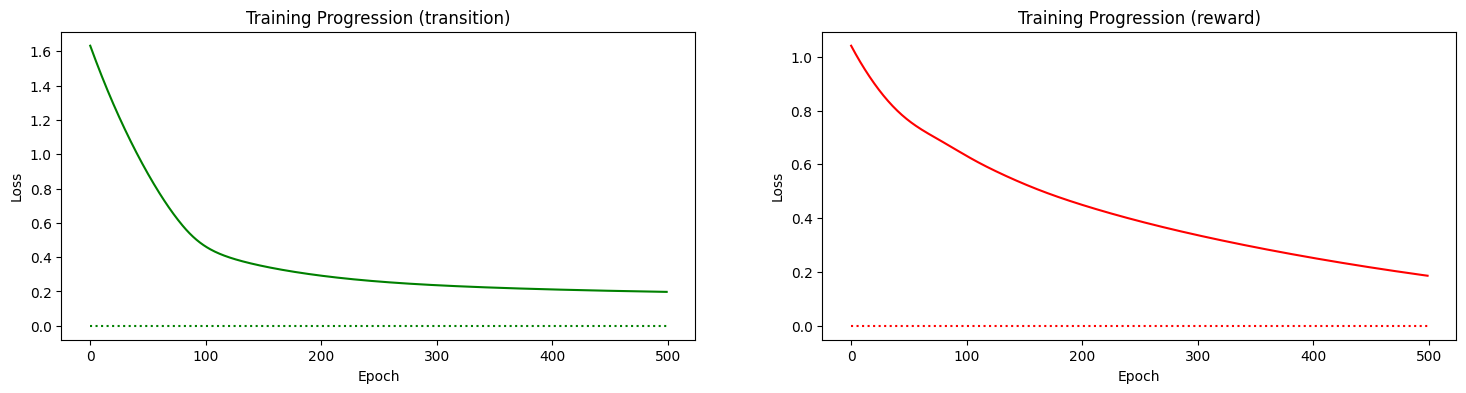

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

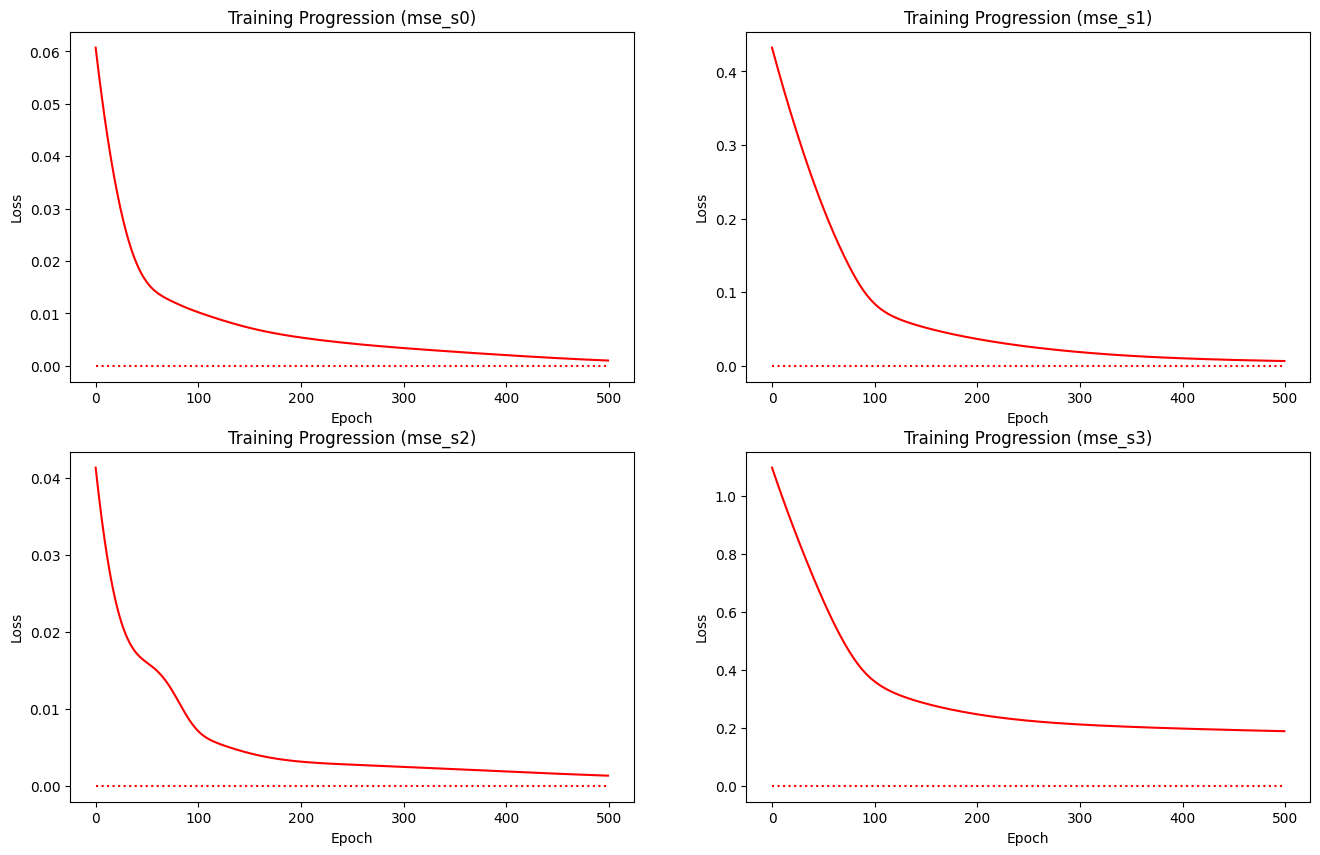

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

# Evaluation

In [ ]:
data.evaluate_model(model, path='testing_data.csv')
results = data.get_evaluation_metrics()
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,estimated_s,estimated_r
0,0,0,"(0.62, 1.2)","(-0.005, -0.042, -0.019, -0.009)",0,1.0,"(-0.006, -0.233, -0.02, 0.183)",1.0,1.0,"(-0.01, -0.042, -0.016, -0.018)","(-0.028, -0.046, -0.0, -0.115)",0.6
1,1,0,"(0.62, 1.2)","(-0.006, -0.233, -0.02, 0.183)",1,1.0,"(-0.01, -0.042, -0.016, -0.018)",1.0,1.0,"(-0.011, 0.149, -0.016, -0.218)","(-0.029, 0.129, 0.009, -0.317)",0.6
2,2,0,"(0.62, 1.2)","(-0.01, -0.042, -0.016, -0.018)",1,1.0,"(-0.011, 0.149, -0.016, -0.218)",1.0,1.0,"(-0.008, 0.34, -0.021, -0.418)","(-0.011, 0.322, -0.012, -0.537)",0.6
3,3,0,"(0.62, 1.2)","(-0.011, 0.149, -0.016, -0.218)",1,1.0,"(-0.008, 0.34, -0.021, -0.418)",1.0,1.0,"(-0.001, 0.531, -0.029, -0.619)","(0.011, 0.511, -0.037, -0.752)",0.6
4,4,0,"(0.62, 1.2)","(-0.008, 0.34, -0.021, -0.418)",1,1.0,"(-0.001, 0.531, -0.029, -0.619)",1.0,1.0,"(0.009, 0.722, -0.041, -0.822)","(0.037, 0.693, -0.063, -0.958)",0.6


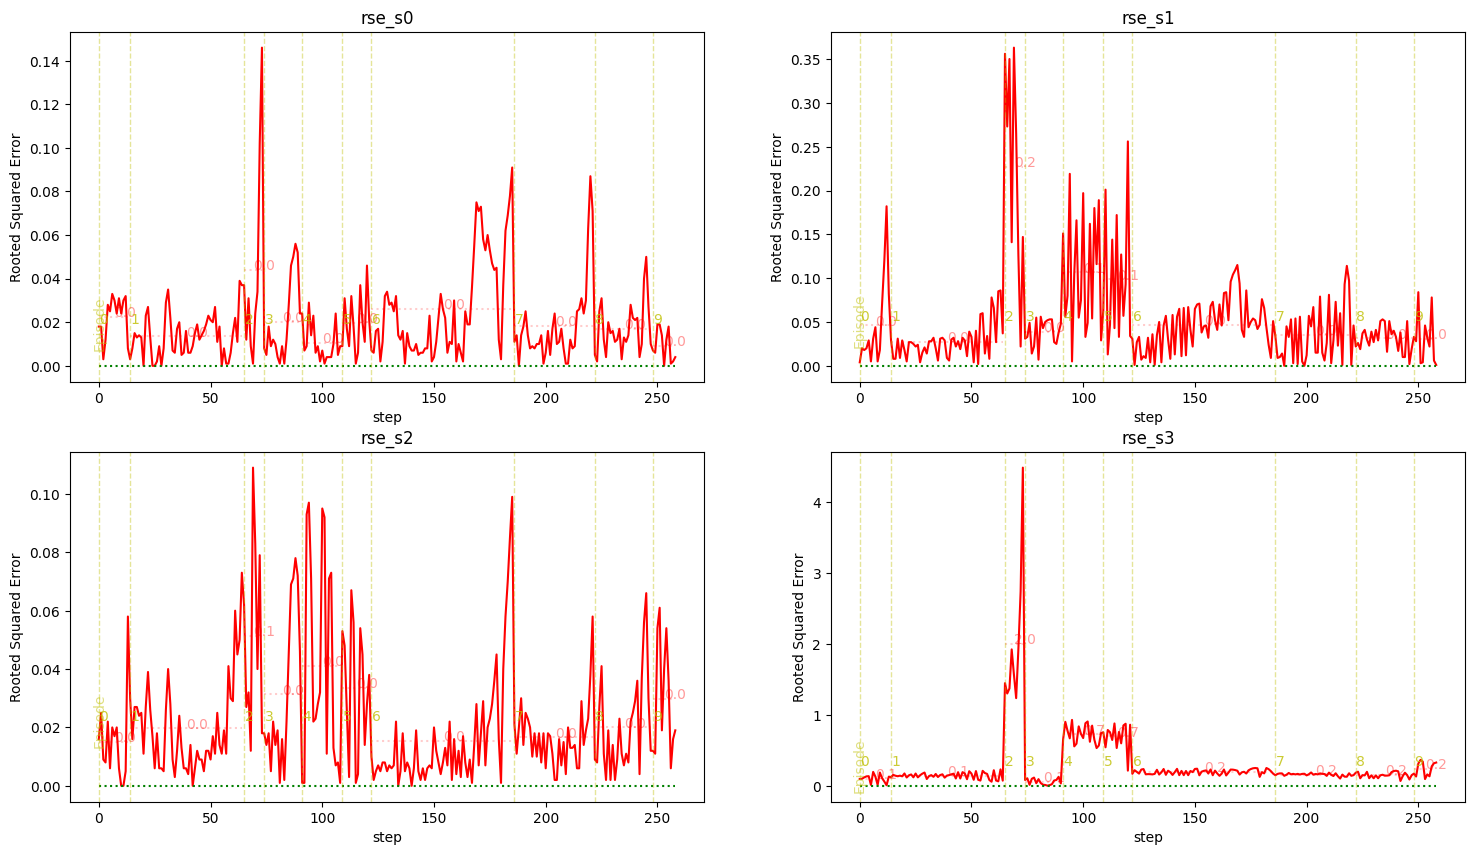

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

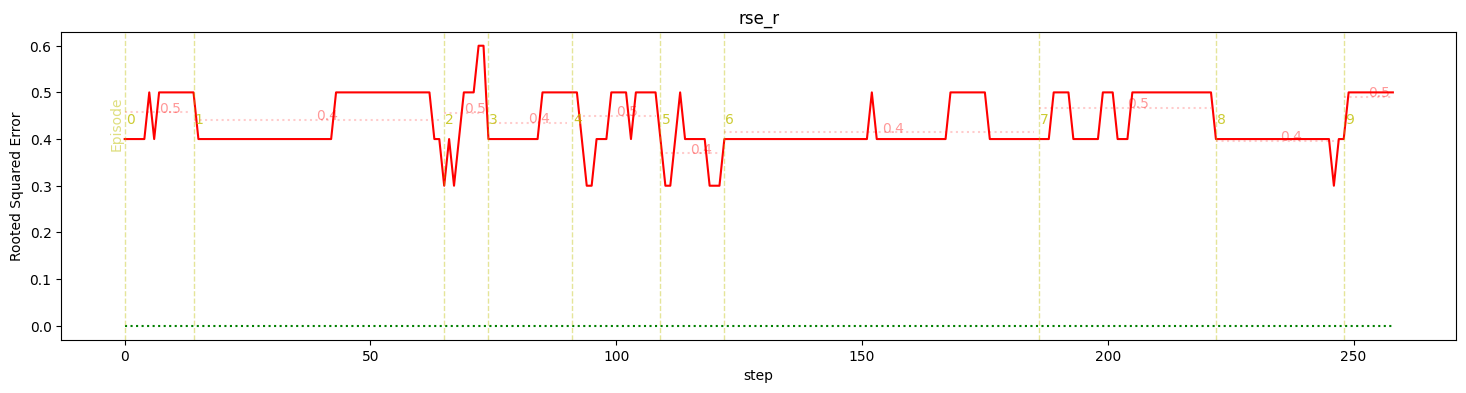

In [8]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

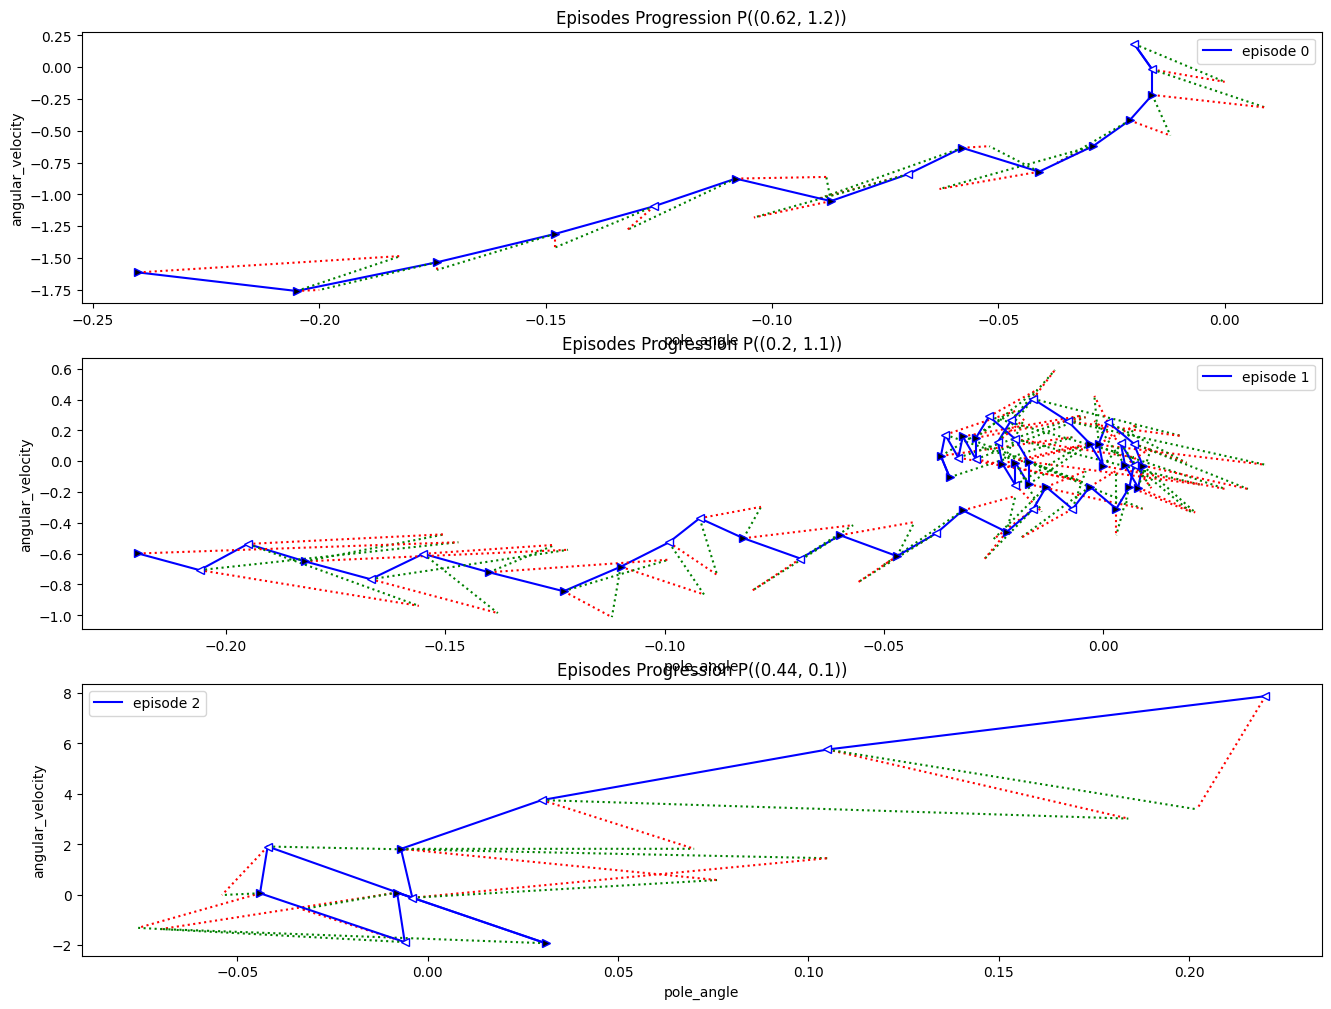

In [9]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()